# Research Notebook
## Haotian Xiao
## Date: 2026 Jan 20 - 2026 Feb 09

# 1: Experience
## Describe at least one research activity you worked on this week. 

My research was conducted within the framework of a **4-step pipeline**（see research journal1 for further details) outlined by our mentor, Dr.Sean Tulin. The ultimate goal is to assess the fit of all physical parameters by comparing modeled gas density to observational data. My primary activity focused on **Step 3**: finalising the temperature profile modeling for the Humphrey dataset and unifying our analytical models into a single framework. 

I performed best model fits for  7 sources from the Humphrey (2006) sample. For the "U-shaped" temperature profiles observed in NGC1407 and NGC4649, I implemented the **Humphrey EQ4** model, which utilizes an exponential transition to capture inner cooling and outer rising behavior:
$$T(r) = (T_0 + T_1 x^{p_1}) e^{-x^{p_e}} + T_2 x^{p_2} (1 - e^{-x^{p_e}})$$
where $x = r/r_c$. For all other sources, the **Humphrey EQ3** or **Vikhlinin Reduced** models were used based on statistical merit.

## Motivation:

The motivation for this rigorous selection is to provide a robust $T_{gas}(r)$ and a stable analytical derivative $dT/dr$ for the **Jeans model (Hydrostatic Equilibrium)** in Step 4:
$$\frac{M_{tot}(r)}{r} = -\frac{k_B T(r)}{G \mu m_p} \left[ \frac{d \ln \rho_{gas}}{d \ln r} + \frac{d \ln T}{d \ln r} \right]$$
Any unphysical "wiggles" caused by overfitting in the temperature profile would be amplified during differentiation, severely destabilizing the gas density solution.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.


2.1: **Model Fitting & AICc Validation:** I implemented the **Corrected AIC (AICc)** to objectively rank candidate models (Humphrey EQ3/4/5 and Vikhlinin Full/Simple/Reduced):
   $$AIC_{c} = \chi^2 + 2k + \frac{2k(k+1)}{N-k-1}$$
   This allowed me to penalize over-parameterized models that lacked empirical support from the sparse data ($N < 7$ in some cases).

2.2: **Model Selection:** Based on the AICc scores, the Humphrey Eq.3 model was optimal for the majority of the sources. However, for the sources exhibiting a U-shaped temperature profile (NGC4649 and NGC1407), I included the Humphrey Eq.4 model, as it is the most efficient formulation capable of capturing this complex shape with the fewest parameters. 

2.3: **Code Unification:** I compiled these optimal parameters, along with the Vikhlinin Reduced model parameters previously established for the Gastaldello data, into a comprehensive Python module (`temperature.py`). I also made a README.md file for instructions on using this Python module.

2.4: **Verification:** I plotted verification graphs for all sources across an extended radial range to visually inspect $T(r)$ and analytically compute $dT/dr$.

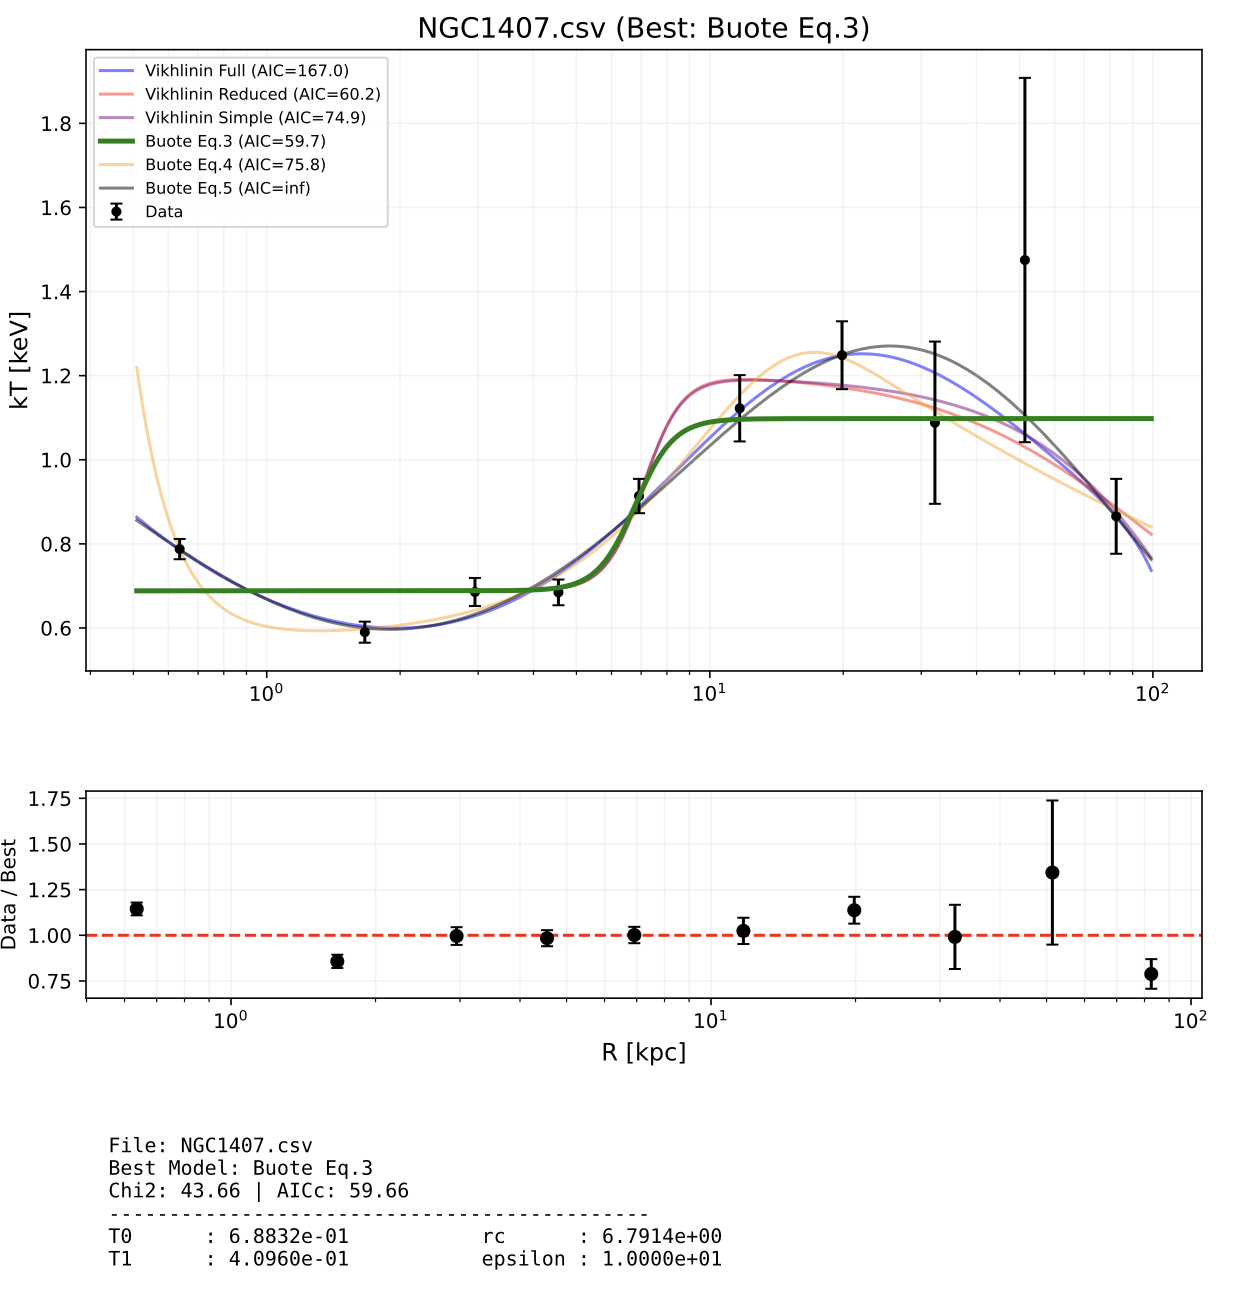

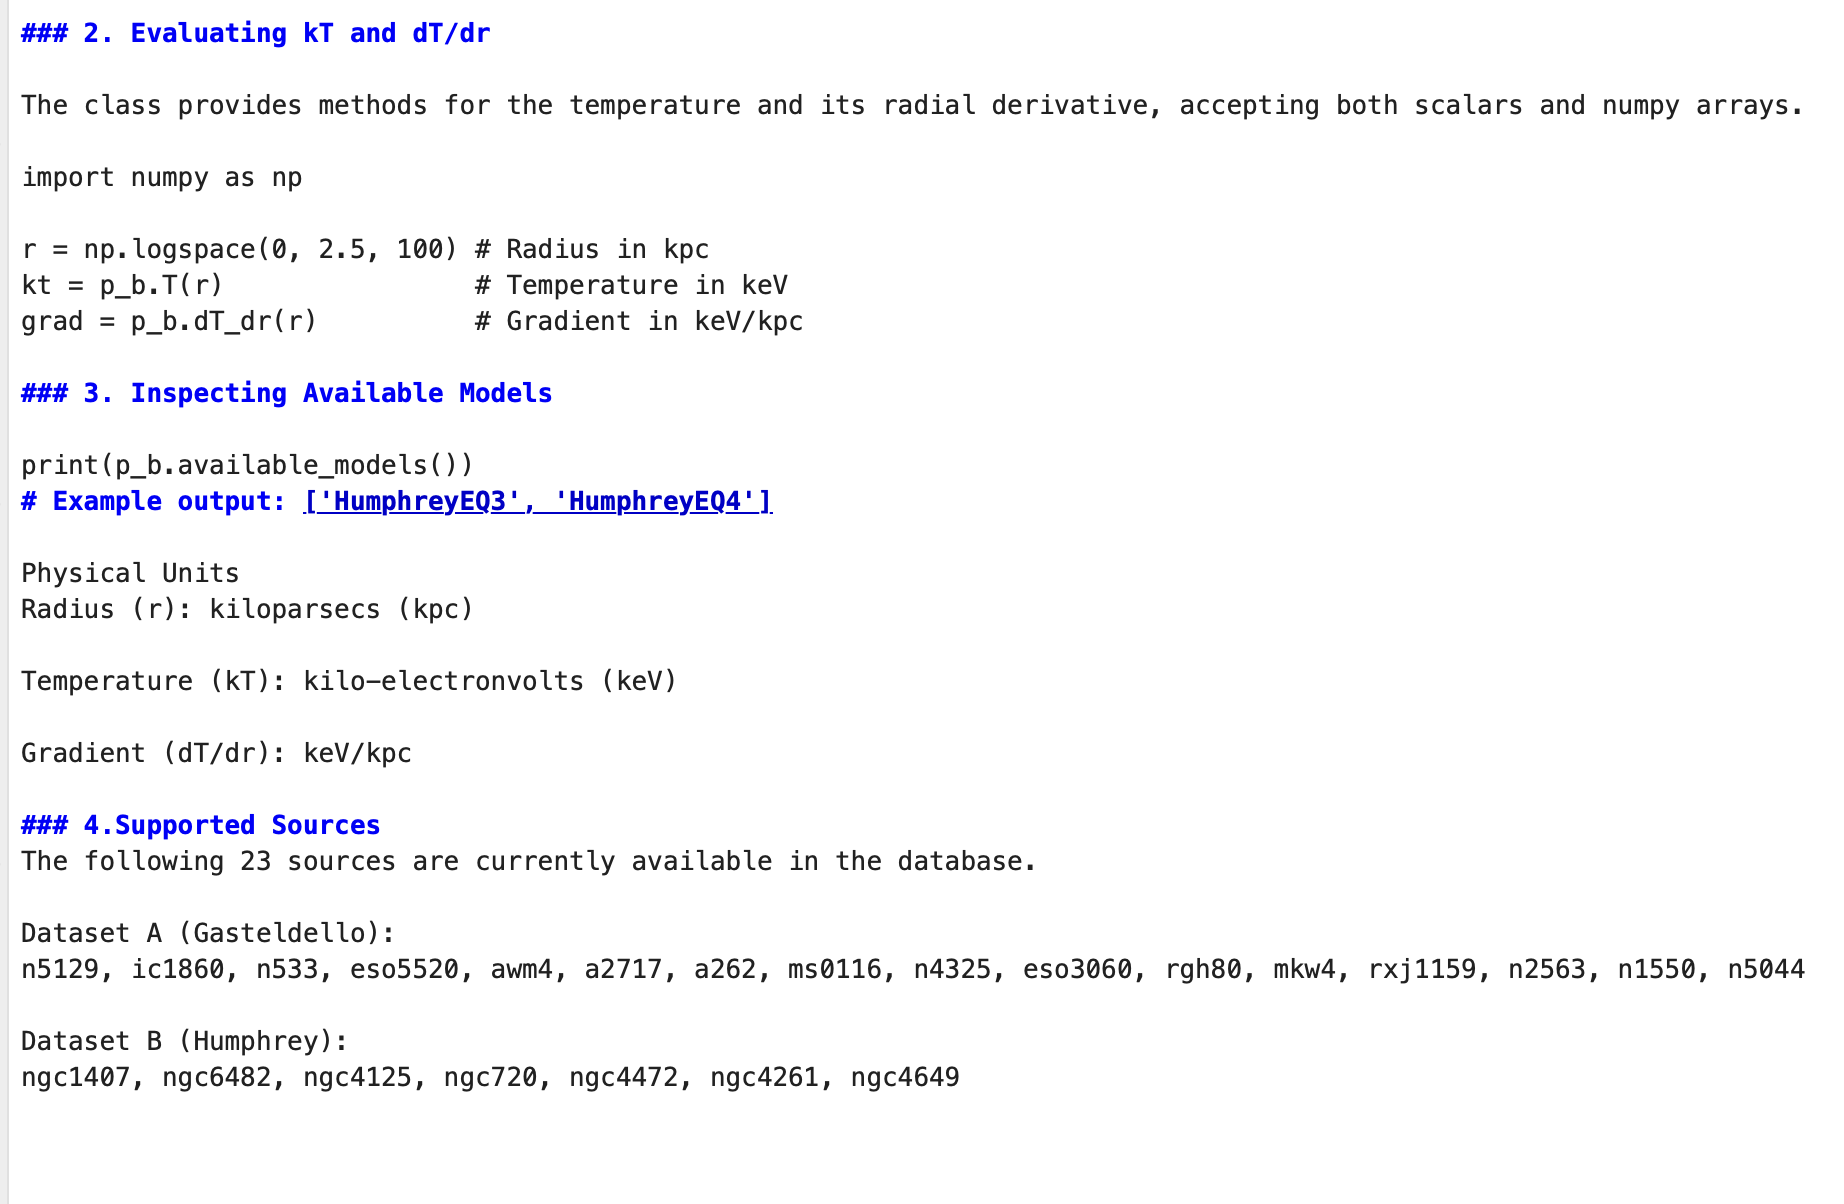

# 3: So what? (What does it mean?)
## Describe your results


The AICc validation proved highly effective in weeding out over-parameterized models that would have otherwise introduced noise.Our verification plots demonstrate that both the temperature profiles and their radial gradients ($dT/dr$) are smooth and physically reasonable across all sources. (For NGC4649 and NGC1407 Humphrey Eq.4 is the physically reasonable model though Humphrey Eq.3 is also smooth. We will test for the errors for these two sources using different models.) 


This successful unification in `temperature.py` means we now have a robust, callable object-oriented framework for any source in our sample, successfully decoupling the temperature modeling phase from the density solving phase.

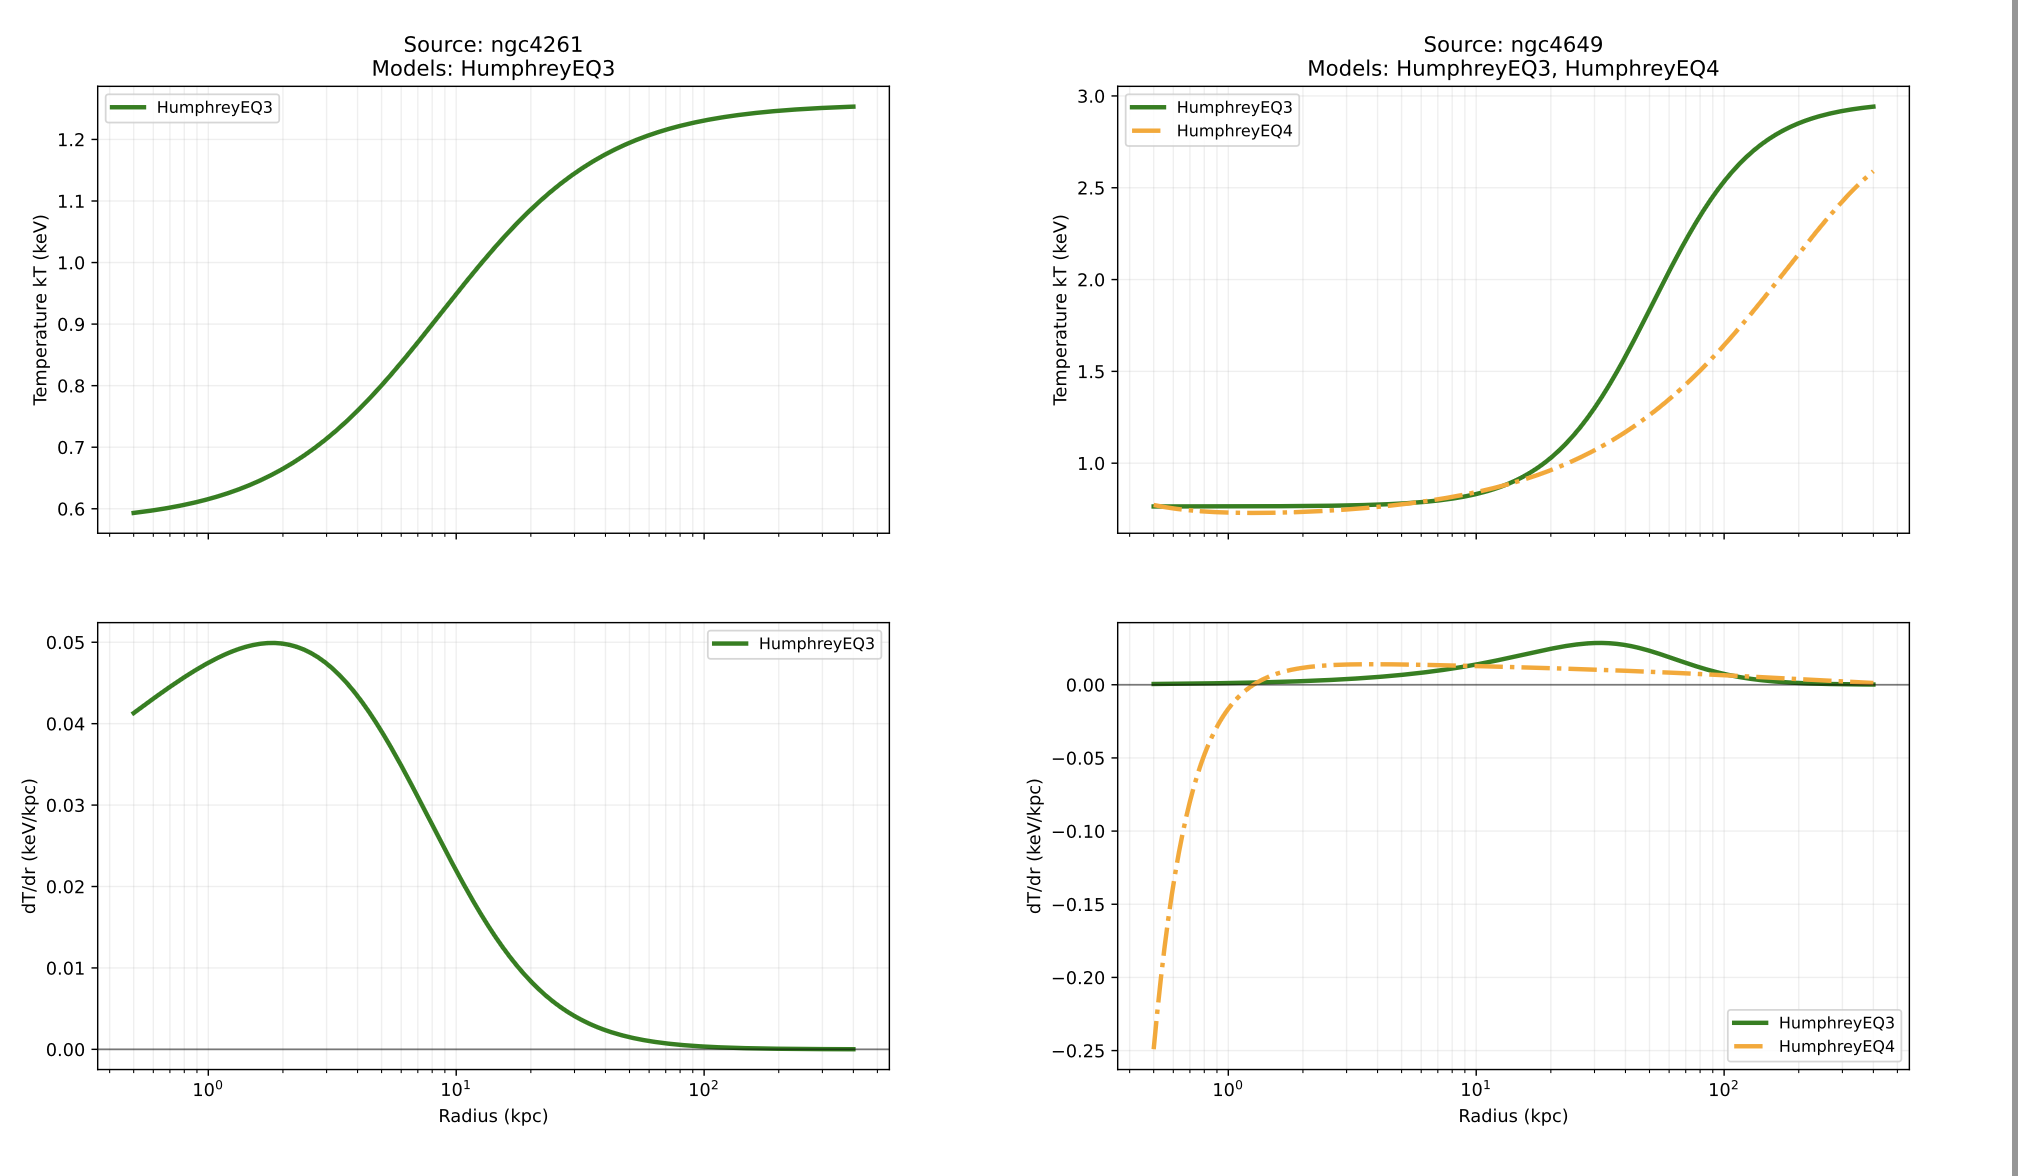

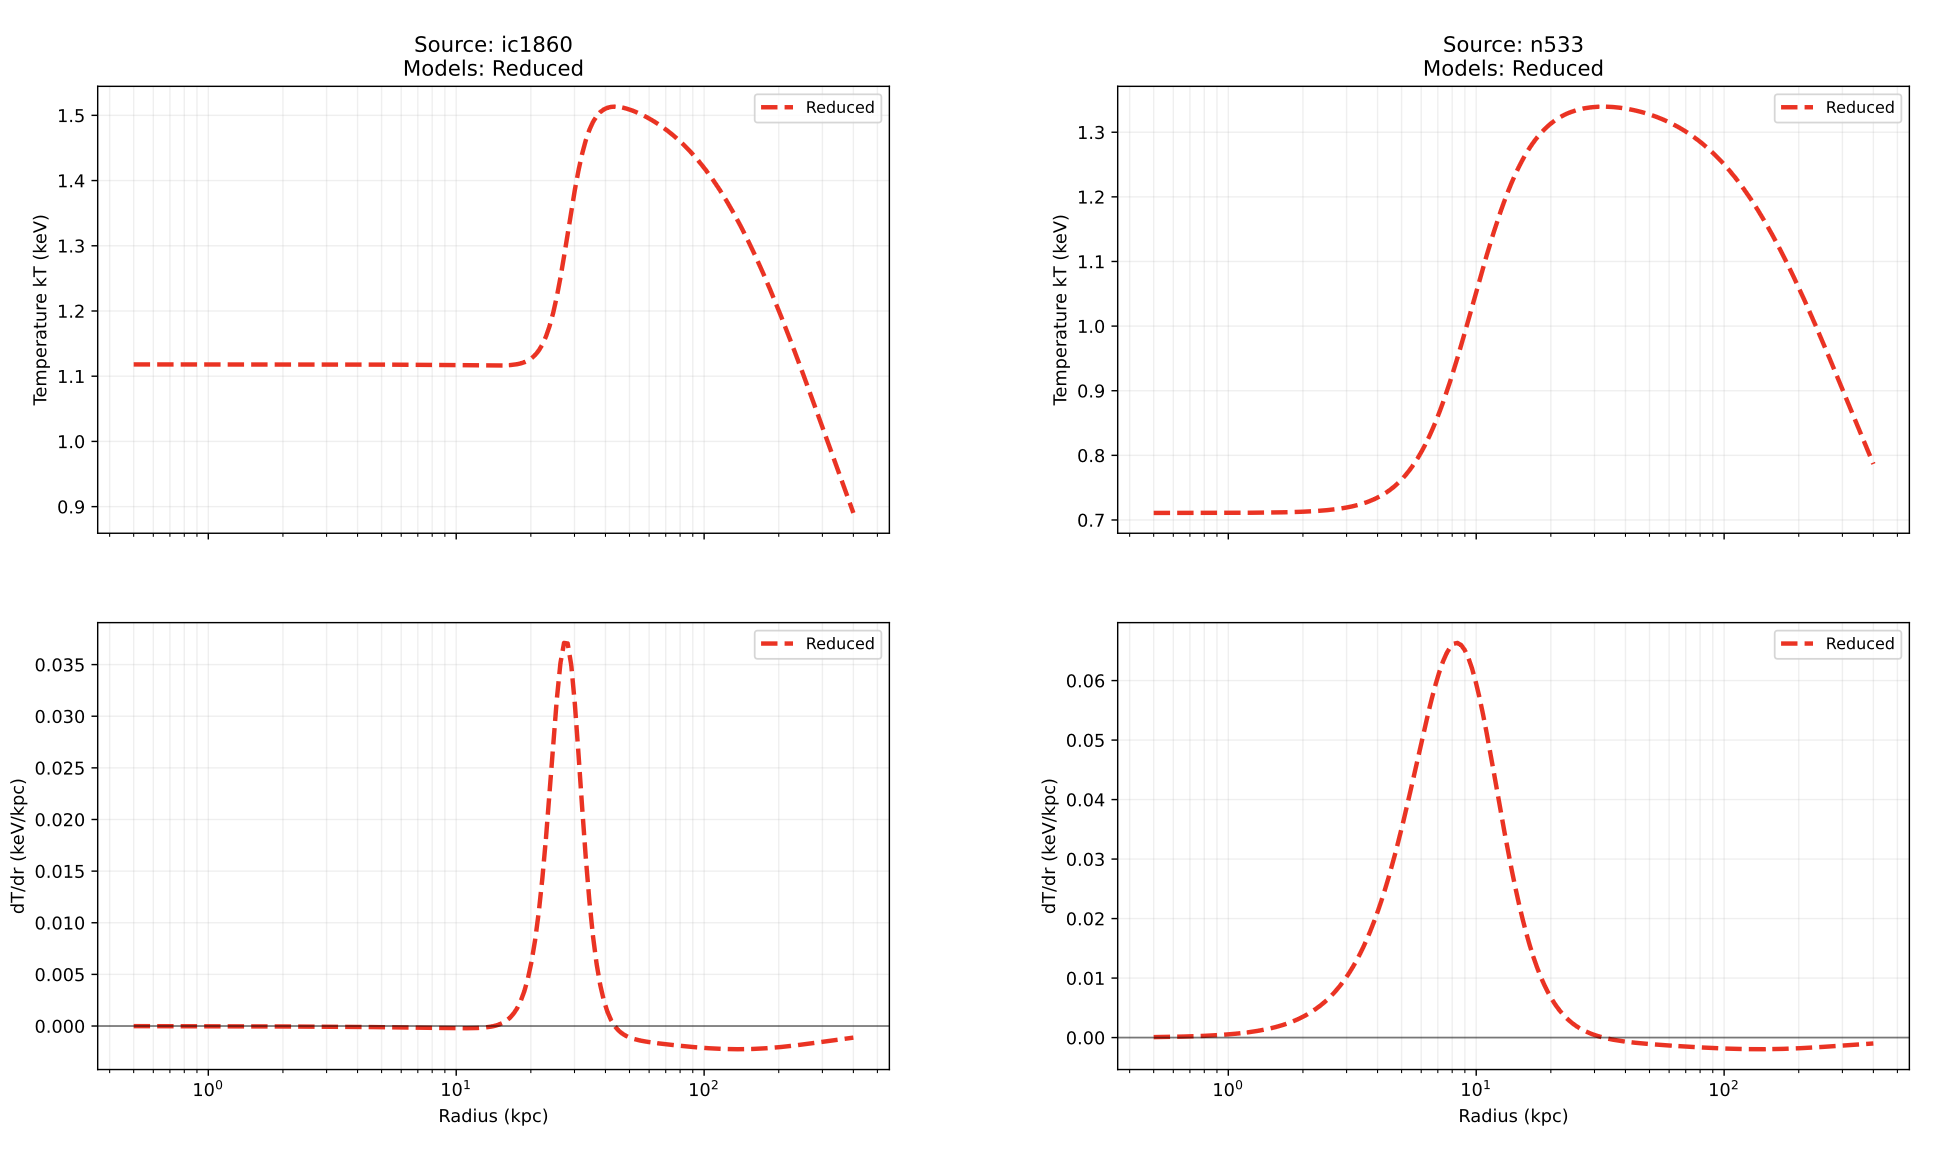



# 4. Now what? (What's next?)
## Plan for the next week

With the temperature profiles securely modeled and analytically differentiable, the next immediate steps are:

4.1: **ODE Solver Integration:** Combine this framework with the gas density work completed by other group members. I will write an `ode_solver` function to solve the Jeans model (Hydrostatic Equilibrium equation).

4.2: **MCMC Implementation:** Apply the `emcee` package to our combined model to perform Markov Chain Monte Carlo analysis . This will allow us to rigorously explore the parameter space and quantify uncertainties in the mass distribution.



# 5. Bibliography

1. Humphrey, P. J., et al. (2006). "A Chandra View of Dark Matter in Early-Type Galaxies." *The Astrophysical Journal*.
2. Vikhlinin, A., et al. (2006). "Chandra Sample of Nearby Relaxed Galaxy Clusters: Mass, Gas Fraction, and Dark Matter Halo Profile." *The Astrophysical Journal*.
3. Gastaldello, F., et al. (2007). "Probing the Dark Matter and Gas Fraction in Relaxed Galaxy Groups with X-Ray Observations." *The Astrophysical Journal*.
4. Foreman-Mackey, D., et al. (2013). "emcee: The MCMC Hammer." *Publications of the Astronomical Society of the Pacific*.

